# Step 05 — Feature-space visualisations and flow trajectories

**A Computer Vision Project — *Flow Matching as a Layer*** · Stage 2
University of Haifa

---

## Purpose

Stage 2's remaining two results:

| Result | What it shows |
| --- | --- |
| **Feature-space visualisations** | Compare original encoder features, features after standard FM, and features after rolled-out FM. Same test examples, same class colours, corresponding prototypes. Projection fitted **jointly** over the compared sets. |
| **Flow trajectories** | Several intermediate FM states with the original feature, the final transported feature, and the class prototype. |

No model is trained here — the representative networks (full data, seed 0) are loaded from
steps 2 and 3, and only forward rollouts on test features are computed.

## How the projection is fitted

The different views need to "correspond to the same low-dimensional
representation" for a side-by-side reading to mean anything. A separate PCA per panel would
rotate and rescale each view independently,
making the three panels **incomparable** — a cluster that appears to tighten might only have
been re-scaled.

So one PCA is fitted on the **concatenation** of every set being compared — original features,
standard-FM outputs, rolled-out outputs, and all prototypes — and that single projection is
applied to all of them. Distances are then comparable across panels.

## A 2D projection is not a measurement

PCA keeps only the two highest-variance directions of a 384- or 512-dimensional space, so a
tighter-looking cluster is suggestive, not conclusive. Section 4 therefore measures the same
claim in the **full** feature space, and the plots are read qualitatively against those
numbers.

## Sections

| # | Section |
| --- | --- |
| 1 | Setup |
| 2 | Class subset and the joint projection |
| 3 | Feature-space comparison — all three combinations |
| 4 | The same claim, measured in full dimensionality |
| 5 | Flow trajectories |
| 6 | Samples and prototypes at intermediate flow times |
| 7 | Reverse flow |
| 8 | Save artefacts & manifest |

## 1 · Setup

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from cvlab.features import load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab.prototypes import l2_normalize

from cvlabfm.flow import FlowConfig, VelocityNet, euler_rollout
from cvlabfm.paths import RESULTS_ROOT, step_dirs

apply_style()
art = ArtifactWriter(*step_dirs("05_visualizations"))

COMBOS = [("resnet18", "DTD"), ("resnet18", "FGVC-Aircraft"), ("dinov2", "FGVC-Aircraft")]
CONFIG = FlowConfig()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

N_CLASSES_SHOWN = 6      # readable subset
T_COMPARE = 4            # matches the headline results table
T_TRAJECTORY = 12        # more intermediate states to actually look at

proto_payload = torch.load(RESULTS_ROOT / "prototypes.pt", weights_only=False)
prototypes = proto_payload["prototypes"]
std_models = torch.load(RESULTS_ROOT / "standard_fm_models.pt", weights_only=False)["state_dicts"]
roll_models = torch.load(RESULTS_ROOT / "rolled_out_fm_models.pt", weights_only=False)["state_dicts"]

print(f"device: {DEVICE}")
print(f"{len(std_models)} standard-FM models, {len(roll_models)} rolled-out models loaded")


def load_net(state_dict, dim):
    net = VelocityNet(dim, CONFIG.hidden_dim, CONFIG.n_hidden).to(DEVICE)
    net.load_state_dict(state_dict)
    net.eval()
    return net

device: cuda
3 standard-FM models, 6 rolled-out models loaded


## 2 · Class subset and the joint projection

Classes are chosen by an **evenly spaced stride** through the sorted class list — not
hand-picked — so the subset is not quietly selected to flatter the method. The same classes,
the same test images and the same colours are used in every panel of a comparison.

In [2]:
def prepare(enc: str, ds: str, T: int):
    '''Return everything needed for one combination's comparison, all projected through a
    single jointly-fitted PCA.'''
    te = load_features(enc, ds, "test")
    protos = prototypes[f"{enc}__{ds}__Kfull__seedNA"]

    classes = np.arange(0, te.n_classes, max(1, te.n_classes // N_CLASSES_SHOWN))[:N_CLASSES_SHOWN]
    mask = np.isin(te.labels.numpy(), classes)
    z0 = l2_normalize(te.features[mask])
    y = te.labels[mask]

    z = z0.to(DEVICE)
    with torch.no_grad():
        z_std = euler_rollout(load_net(std_models[f"{enc}__{ds}__Kfull__seed0"], te.dim), z, T).cpu()
        z_roll = euler_rollout(load_net(roll_models[f"{enc}__{ds}__Kfull__seed0__T{T}"], te.dim), z, T).cpu()

    # ONE projection fitted over every set being compared, so the panels are commensurable.
    joint = torch.cat([z0, z_std, z_roll, protos[classes]]).numpy()
    pca = PCA(n_components=2, random_state=0).fit(joint)

    views = {
        "original": pca.transform(z0.numpy()),
        "standard FM": pca.transform(z_std.numpy()),
        "rolled-out FM": pca.transform(z_roll.numpy()),
    }
    return {
        "views": views, "protos_2d": pca.transform(protos[classes].numpy()),
        "labels": y.numpy(), "classes": classes, "class_names": te.classes,
        "raw": {"original": z0, "standard FM": z_std, "rolled-out FM": z_roll},
        "protos_full": protos, "explained": pca.explained_variance_ratio_.sum(),
    }


prepared = {}
for enc, ds in COMBOS:
    prepared[(enc, ds)] = prepare(enc, ds, T_COMPARE)
    p = prepared[(enc, ds)]
    print(f"{enc}/{ds}: {len(p['labels'])} test images, {N_CLASSES_SHOWN} classes, "
          f"PCA captures {100*p['explained']:.1f}% of variance")

resnet18/DTD: 240 test images, 6 classes, PCA captures 22.8% of variance
resnet18/FGVC-Aircraft: 200 test images, 6 classes, PCA captures 23.8% of variance
dinov2/FGVC-Aircraft: 200 test images, 6 classes, PCA captures 56.9% of variance


The variance captured is modest — a reminder that these plots compress hundreds of dimensions
into two and should be read as illustrations of a trend, with section 4 supplying the actual
evidence.

## 3 · Feature-space comparison

For each combination: the original encoder features, the same images after
standard FM, and after rolled-out FM — one shared projection, one colour per class, stars for
that class's prototype.

  saved plot  -> plots/feature_space_dinov2_aircraft.png


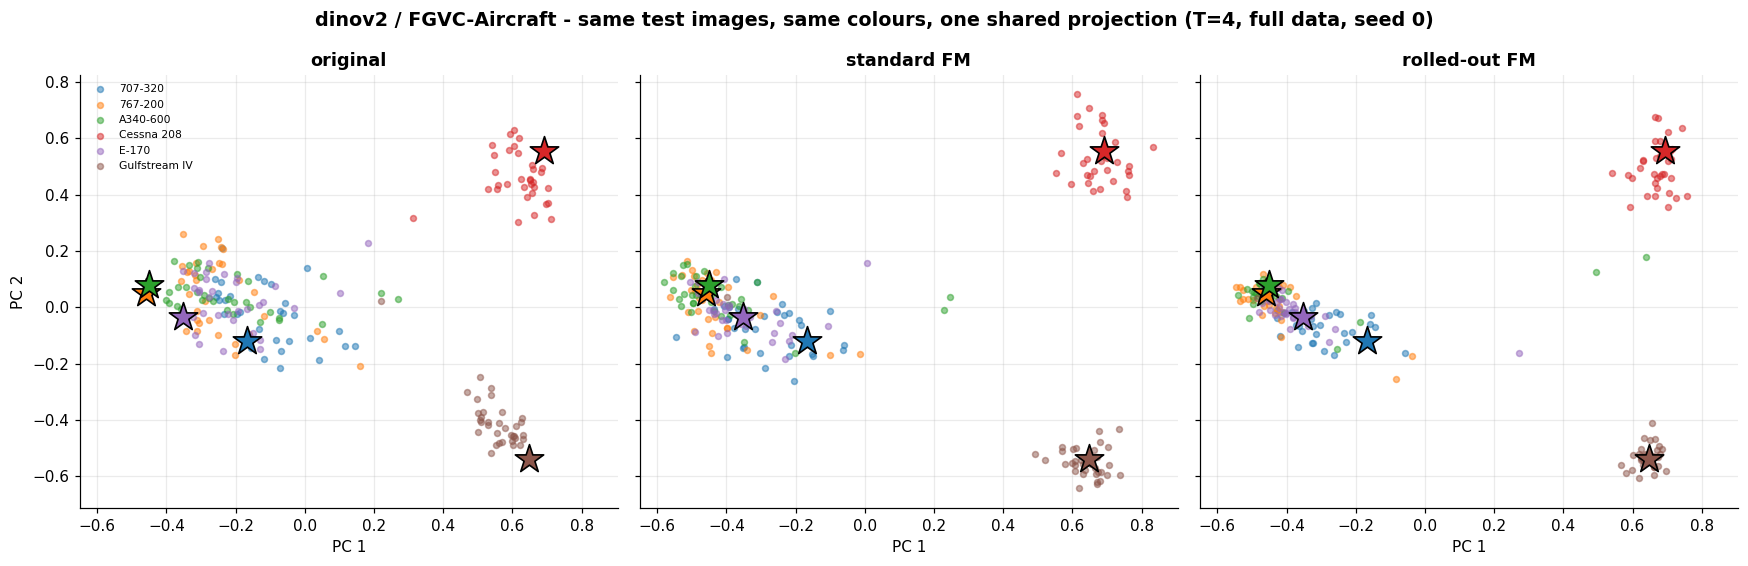

In [3]:
PALETTE = plt.cm.tab10(np.linspace(0, 1, 10))


def comparison_figure(enc: str, ds: str, name: str):
    p = prepared[(enc, ds)]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

    for ax, (title, coords) in zip(axes, p["views"].items()):
        for j, c in enumerate(p["classes"]):
            sel = p["labels"] == c
            ax.scatter(coords[sel, 0], coords[sel, 1], s=15, alpha=0.5,
                       color=PALETTE[j], label=p["class_names"][c][:16] if ax is axes[0] else None)
            ax.scatter(*p["protos_2d"][j], marker="*", s=380, color=PALETTE[j],
                       edgecolor="black", linewidth=1.1, zorder=6)
        ax.set_title(title, fontsize=11.5)
        ax.set_xlabel("PC 1")
    axes[0].set_ylabel("PC 2")
    axes[0].legend(fontsize=7, loc="best")

    fig.suptitle(f"{enc} / {ds} - same test images, same colours, one shared projection "
                 f"(T={T_COMPARE}, full data, seed 0)", fontsize=12.5, fontweight="bold")
    fig.tight_layout()
    art.figure(fig, name)
    plt.show()


comparison_figure("dinov2", "FGVC-Aircraft", "feature_space_dinov2_aircraft")

The combination where the FM layer helps most (+22.3 pp). The original features overlap
heavily; after either flow the classes contract toward their prototypes.

  saved plot  -> plots/feature_space_resnet18_dtd.png


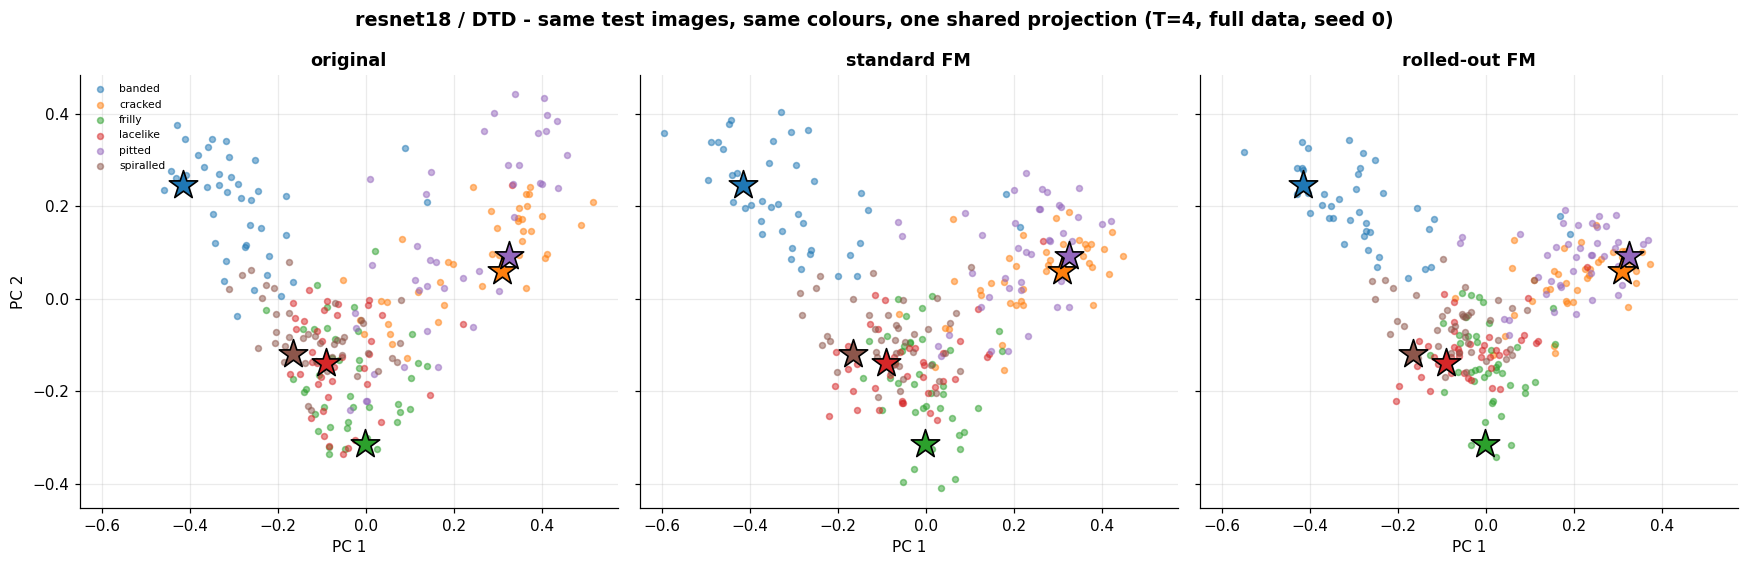

In [4]:
comparison_figure("resnet18", "DTD", "feature_space_resnet18_dtd")

The combination where the FM layer **hurts** (−1.6 pp at $K=5$, and rolled-out is worse still).
Worth showing precisely because the picture looks superficially similar to the one above — the
clusters contract here too — which is exactly why a visual impression cannot substitute for the
accuracy table.

  saved plot  -> plots/feature_space_resnet18_aircraft.png


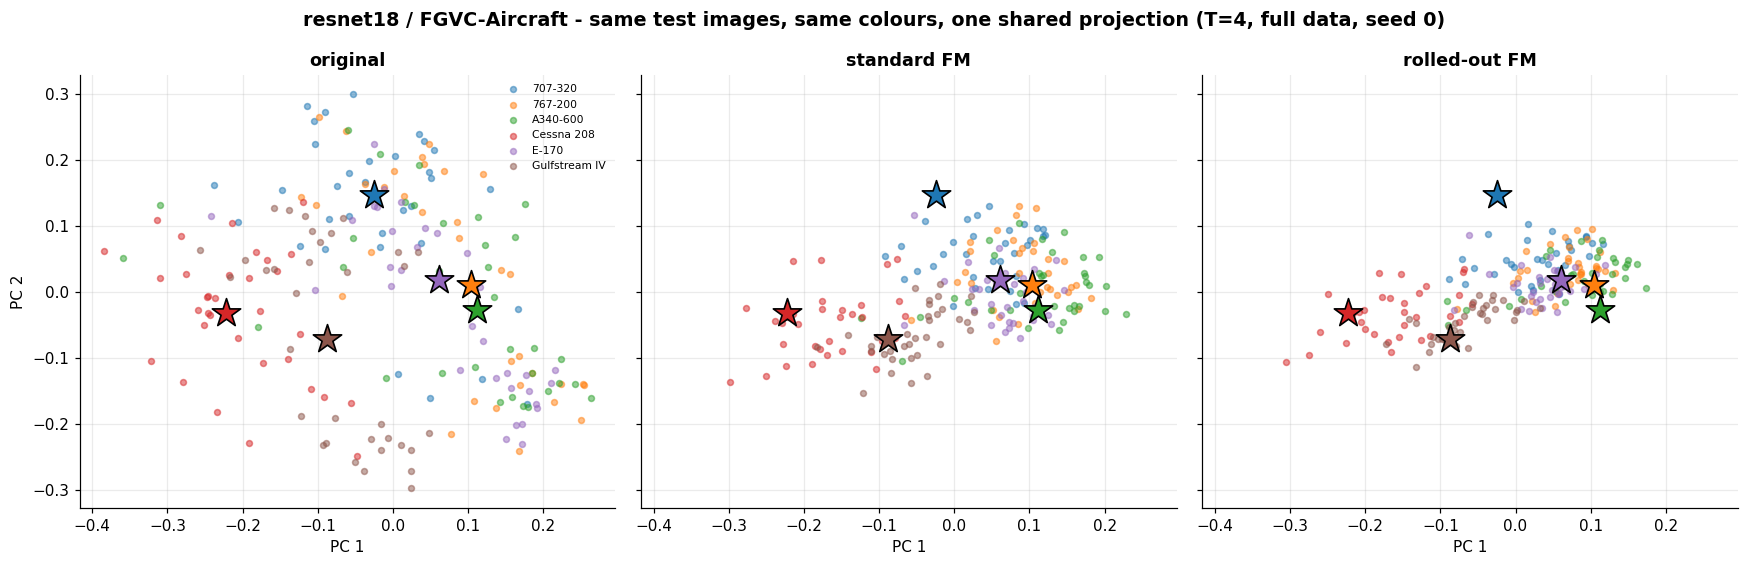

In [5]:
comparison_figure("resnet18", "FGVC-Aircraft", "feature_space_resnet18_aircraft")

## 4 · The same claim, measured in full dimensionality

The panels above suggest the flows contract each class toward its prototype. That is a claim
about the **full** feature space, so it is measured there rather than in the 2D projection.

- **spread** — mean distance from a class's test features to that class's own prototype
  (lower = tighter);
- **separation** — mean distance between prototypes of different classes (this is fixed by the
  prototypes and does not change with the flow, so it is a constant reference);
- **ratio** — spread / separation. Lower is a tighter class relative to how far apart the
  classes are.

If the flows genuinely contract classes, the ratio must fall. Whether that *helps* is a
separate question the accuracy table already answered.

In [6]:
geom_rows = []
for enc, ds in COMBOS:
    p = prepared[(enc, ds)]
    protos_sel = p["protos_full"][p["classes"]]
    # Fixed reference: how far apart the prototypes are from each other.
    dists = torch.cdist(protos_sel, protos_sel)
    separation = dists[~torch.eye(len(protos_sel), dtype=bool)].mean().item()

    for view, feats in p["raw"].items():
        own = p["protos_full"][torch.as_tensor(p["labels"])]
        spread = (feats - own).norm(dim=1).mean().item()
        geom_rows.append({
            "encoder": enc, "dataset": ds, "view": view,
            "spread": round(spread, 4),
            "separation": round(separation, 4),
            "ratio": round(spread / separation, 4),
        })

geometry = pd.DataFrame(geom_rows)
art.table(geometry, "feature_geometry")
geometry

  saved table -> tables/feature_geometry.csv  (9 rows)


,encoder,dataset,view,spread,separation,ratio
0,resnet18,DTD,original,0.7137,0.6873,1.0383
1,resnet18,DTD,standard FM,0.4233,0.6873,0.6159
2,resnet18,DTD,rolled-out FM,0.3671,0.6873,0.5341
3,resnet18,FGVC-Aircraft,original,0.4536,0.2837,1.5993
4,resnet18,FGVC-Aircraft,standard FM,0.2205,0.2837,0.7772
5,resnet18,FGVC-Aircraft,rolled-out FM,0.1766,0.2837,0.6226
6,dinov2,FGVC-Aircraft,original,0.7543,0.9764,0.7725
7,dinov2,FGVC-Aircraft,standard FM,0.3561,0.9764,0.3647
8,dinov2,FGVC-Aircraft,rolled-out FM,0.3082,0.9764,0.3157


  saved plot  -> plots/contraction_measured.png

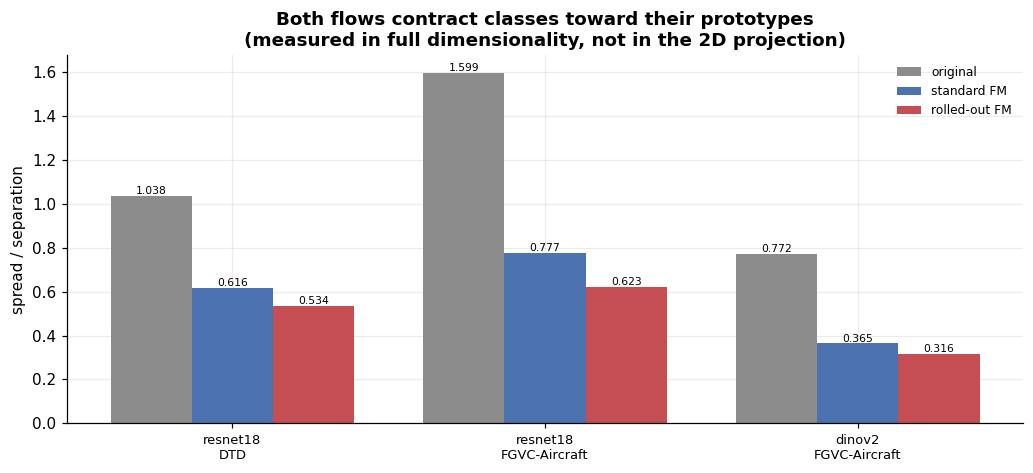

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
views = ["original", "standard FM", "rolled-out FM"]
x = np.arange(len(COMBOS))
width = 0.26

for i, (view, c) in enumerate(zip(views, ["#8C8C8C", "#4C72B0", "#C44E52"])):
    vals = [geometry[(geometry.encoder == e) & (geometry.dataset == d)
                     & (geometry.view == view)].ratio.iloc[0] for e, d in COMBOS]
    bars = ax.bar(x + (i - 1) * width, vals, width, color=c, label=view)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.008, f"{v:.3f}",
                ha="center", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f"{e}\n{d}" for e, d in COMBOS], fontsize=8.5)
ax.set_ylabel("spread / separation")
ax.set_title("Both flows contract classes toward their prototypes\n"
             "(measured in full dimensionality, not in the 2D projection)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
fig.tight_layout()
art.figure(fig, "contraction_measured")
plt.show()

The contraction is real and rolled-out contracts *more* in every combination — consistent with
step 3, where rolled-out reached the prototype more closely yet classified worse. Contraction
toward the correct prototype is not the same thing as separation from the wrong ones.

## 5 · Flow trajectories

A small number of test examples, each shown with its intermediate states,
its original feature, its final transported feature, and its class prototype.

$T = 12$ is used here rather than $T = 4$ purely so there are more intermediate states to see;
the accuracy difference between the two is under 1 pp.

  saved plot  -> plots/flow_trajectories_dinov2.png


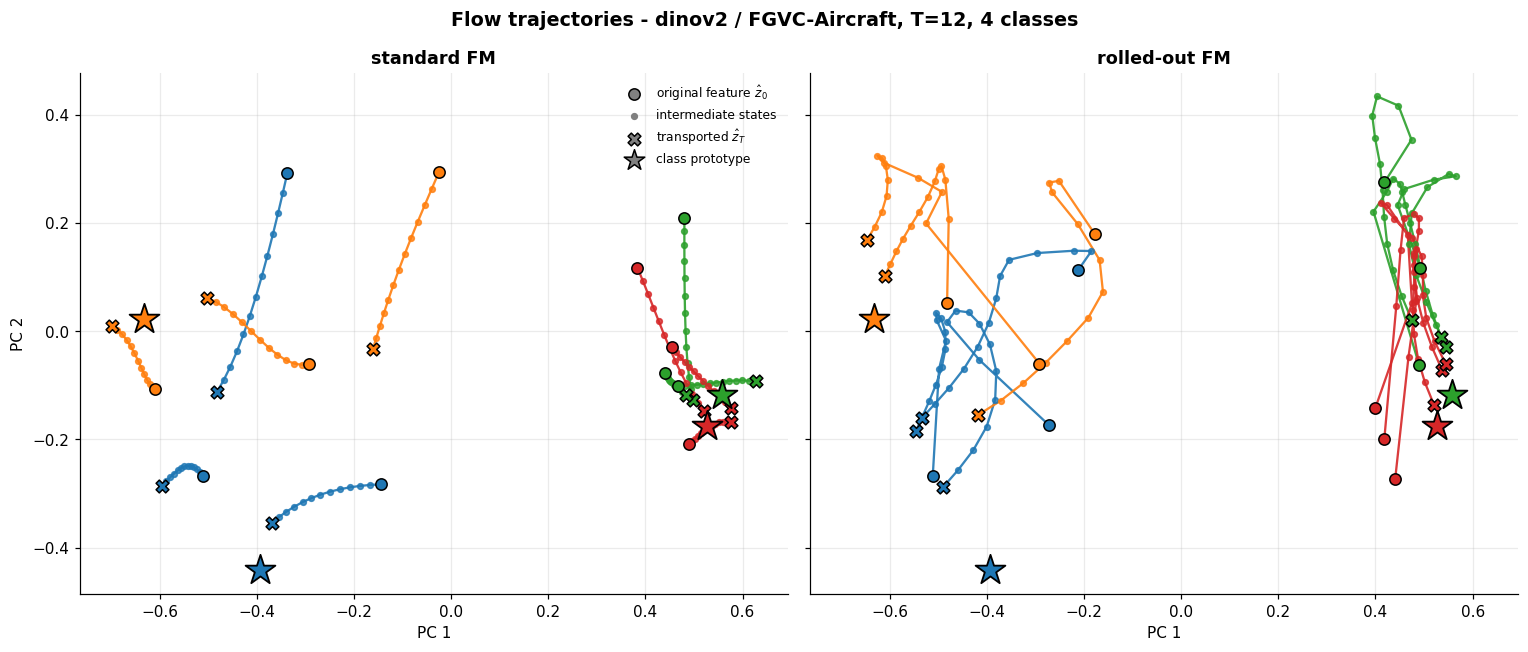

In [8]:
def trajectory_figure(enc: str, ds: str, name: str, n_per_class: int = 3, n_classes: int = 4):
    te = load_features(enc, ds, "test")
    protos = prototypes[f"{enc}__{ds}__Kfull__seedNA"]
    classes = np.arange(0, te.n_classes, max(1, te.n_classes // n_classes))[:n_classes]

    mask = np.isin(te.labels.numpy(), classes)
    z0 = l2_normalize(te.features[mask])
    y = te.labels[mask].numpy()

    nets = {
        "standard FM": load_net(std_models[f"{enc}__{ds}__Kfull__seed0"], te.dim),
        "rolled-out FM": load_net(roll_models[f"{enc}__{ds}__Kfull__seed0__T{T_TRAJECTORY}"], te.dim),
    }
    trajs = {}
    with torch.no_grad():
        for label, net in nets.items():
            _, tr = euler_rollout(net, z0.to(DEVICE), T_TRAJECTORY, return_trajectory=True)
            trajs[label] = tr.cpu()

    joint = torch.cat([z0] + [t.reshape(-1, te.dim) for t in trajs.values()]
                      + [protos[classes]]).numpy()
    pca = PCA(n_components=2, random_state=0).fit(joint)
    P = pca.transform(protos[classes].numpy())

    rng = np.random.default_rng(0)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    for ax, (label, tr) in zip(axes, trajs.items()):
        for j, c in enumerate(classes):
            idx = np.where(y == c)[0]
            for i in rng.choice(idx, size=min(n_per_class, len(idx)), replace=False):
                path = pca.transform(tr[i].numpy())
                ax.plot(path[:, 0], path[:, 1], color=PALETTE[j], lw=1.5, alpha=0.9, zorder=3)
                ax.scatter(path[1:-1, 0], path[1:-1, 1], s=14, color=PALETTE[j],
                           alpha=0.8, zorder=4)
                ax.scatter(*path[0], s=55, color=PALETTE[j], marker="o",
                           edgecolor="black", linewidth=1.0, zorder=5)
                ax.scatter(*path[-1], s=70, color=PALETTE[j], marker="X",
                           edgecolor="black", linewidth=1.0, zorder=5)
            ax.scatter(*P[j], marker="*", s=420, color=PALETTE[j],
                       edgecolor="black", linewidth=1.2, zorder=6)
        ax.set_title(label, fontsize=11.5)
        ax.set_xlabel("PC 1")

    axes[0].set_ylabel("PC 2")
    axes[0].scatter([], [], s=55, color="grey", marker="o", edgecolor="black",
                    label="original feature $\\hat z_0$")
    axes[0].scatter([], [], s=14, color="grey", label="intermediate states")
    axes[0].scatter([], [], s=70, color="grey", marker="X", edgecolor="black",
                    label="transported $\\hat z_T$")
    axes[0].scatter([], [], s=200, color="grey", marker="*", edgecolor="black",
                    label="class prototype")
    axes[0].legend(fontsize=8, loc="best")

    fig.suptitle(f"Flow trajectories - {enc} / {ds}, T={T_TRAJECTORY}, {n_classes} classes",
                 fontsize=12.5, fontweight="bold")
    fig.tight_layout()
    art.figure(fig, name)
    plt.show()


trajectory_figure("dinov2", "FGVC-Aircraft", "flow_trajectories_dinov2")

  saved plot  -> plots/flow_trajectories_resnet18_dtd.png


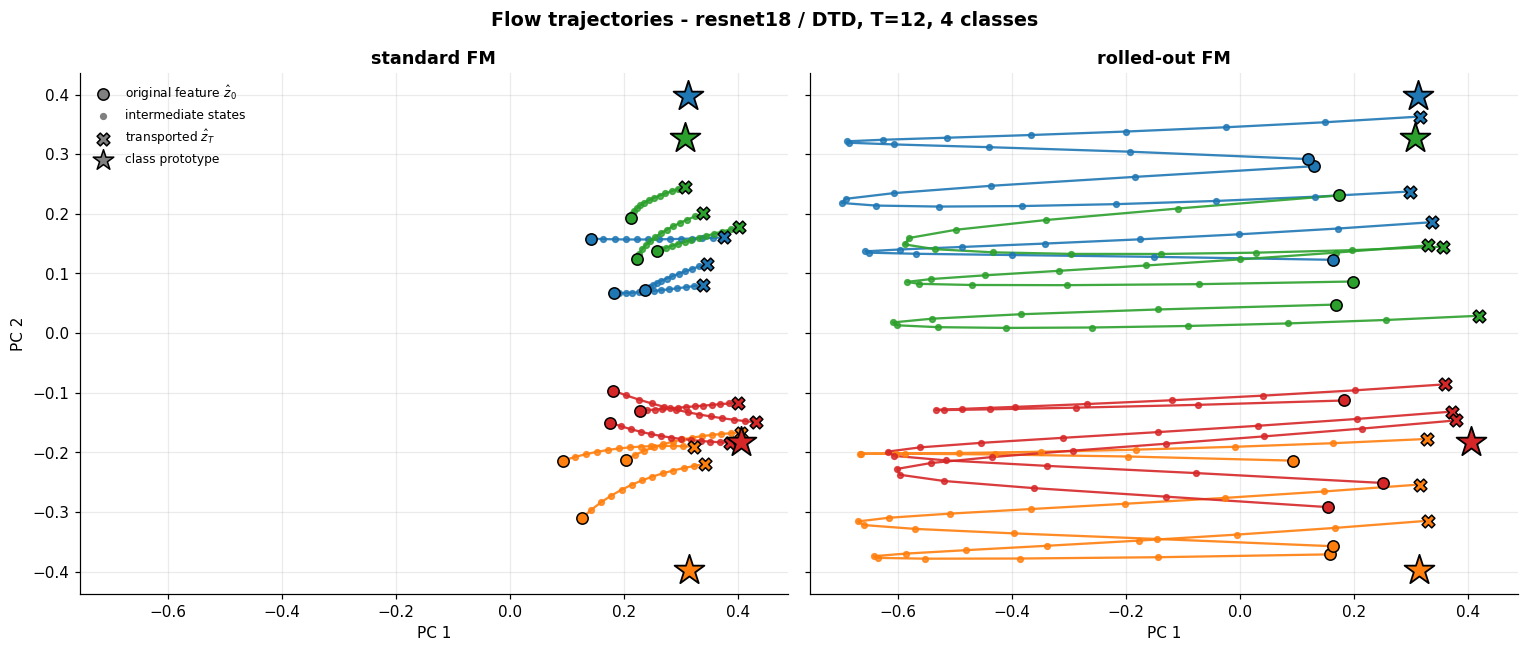

In [9]:
trajectory_figure("resnet18", "DTD", "flow_trajectories_resnet18_dtd")

## 6 · Comparing samples and prototypes at intermediate flow times

A further exploration beyond the two core results. Two complementary readings of
the same rollout:

- **how far** the samples are from the prototypes at each step $k$ (geometry);
- **how classifiable** the intermediate state $\hat z_k$ is at each step (behaviour).

Together they separate a flow that moves steadily toward the target from one that reaches it
by an arbitrary route.

  saved table -> tables/distance_by_step.csv  (78 rows)


  saved plot  -> plots/distance_by_step.png


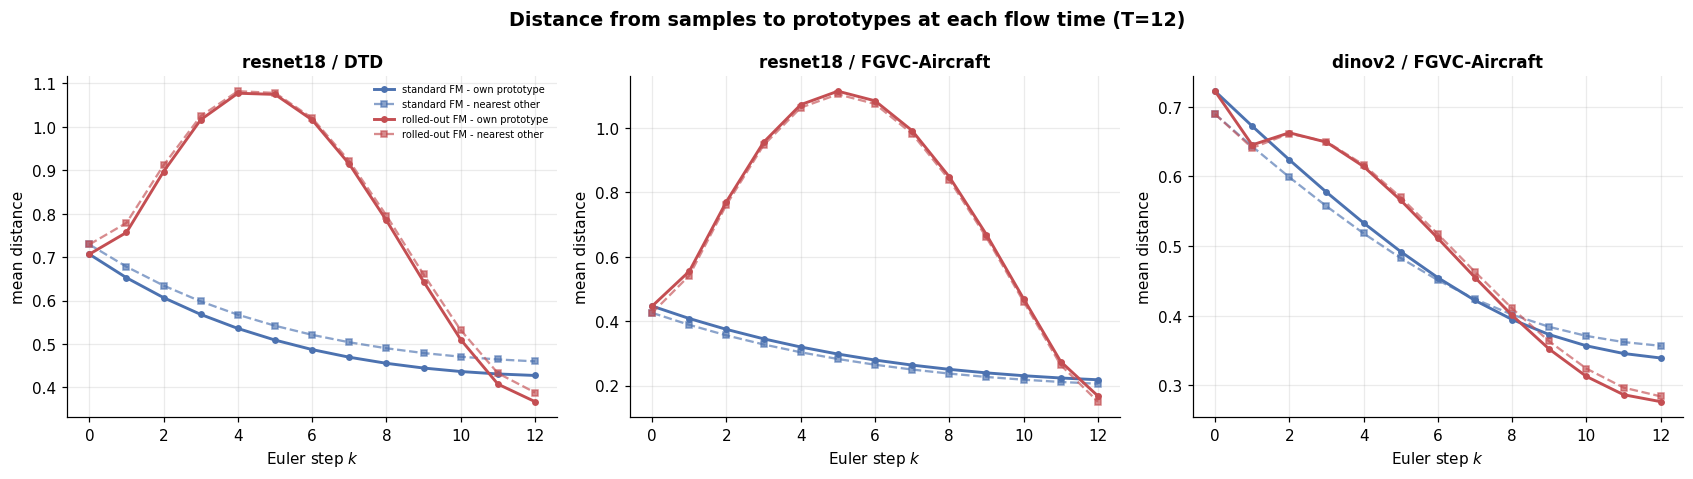

In [10]:
dist_rows = []
for enc, ds in COMBOS:
    te = load_features(enc, ds, "test")
    protos = prototypes[f"{enc}__{ds}__Kfull__seedNA"].to(DEVICE)
    z = l2_normalize(te.features).to(DEVICE)
    own = protos[te.labels.to(DEVICE)]

    for label, store in [("standard FM", std_models[f"{enc}__{ds}__Kfull__seed0"]),
                         ("rolled-out FM", roll_models[f"{enc}__{ds}__Kfull__seed0__T{T_TRAJECTORY}"])]:
        net = load_net(store, te.dim)
        with torch.no_grad():
            _, tr = euler_rollout(net, z, T_TRAJECTORY, return_trajectory=True)
            for k in range(T_TRAJECTORY + 1):
                state = tr[:, k]
                dist_rows.append({
                    "encoder": enc, "dataset": ds, "method": label, "step": k,
                    "dist_own": round((state - own).norm(dim=1).mean().item(), 4),
                    "dist_nearest_other": round(
                        (torch.cdist(state, protos)
                         .scatter(1, te.labels.to(DEVICE)[:, None], float("inf"))
                         .min(dim=1).values.mean().item()), 4),
                })

distances = pd.DataFrame(dist_rows)
art.table(distances, "distance_by_step")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), sharex=True)
for ax, (enc, ds) in zip(axes, COMBOS):
    for label, c in [("standard FM", "#4C72B0"), ("rolled-out FM", "#C44E52")]:
        sel = distances[(distances.encoder == enc) & (distances.dataset == ds)
                        & (distances.method == label)]
        ax.plot(sel.step, sel.dist_own, marker="o", ms=3.5, lw=1.9, color=c,
                label=f"{label} - own prototype")
        ax.plot(sel.step, sel.dist_nearest_other, marker="s", ms=3.5, lw=1.5, ls="--",
                color=c, alpha=0.65, label=f"{label} - nearest other")
    ax.set_xlabel("Euler step $k$"); ax.set_ylabel(r"mean distance")
    ax.set_title(f"{enc} / {ds}", fontsize=11)
    if ax is axes[0]:
        ax.legend(fontsize=6.5)

fig.suptitle(f"Distance from samples to prototypes at each flow time (T={T_TRAJECTORY})",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
art.figure(fig, "distance_by_step")
plt.show()

Both flows close the gap to the **own** prototype (solid) — but they close the gap to the
**nearest competing** prototype (dashed) at nearly the same rate. The two curves stay close
together, which is the geometric form of the finding from step 3: the transport pulls features
toward the prototype cloud as a whole, not specifically toward the correct member of it.

The behavioural view below shows what that costs.

  saved table -> tables/accuracy_by_step.csv  (78 rows)


  saved plot  -> plots/accuracy_by_step.png


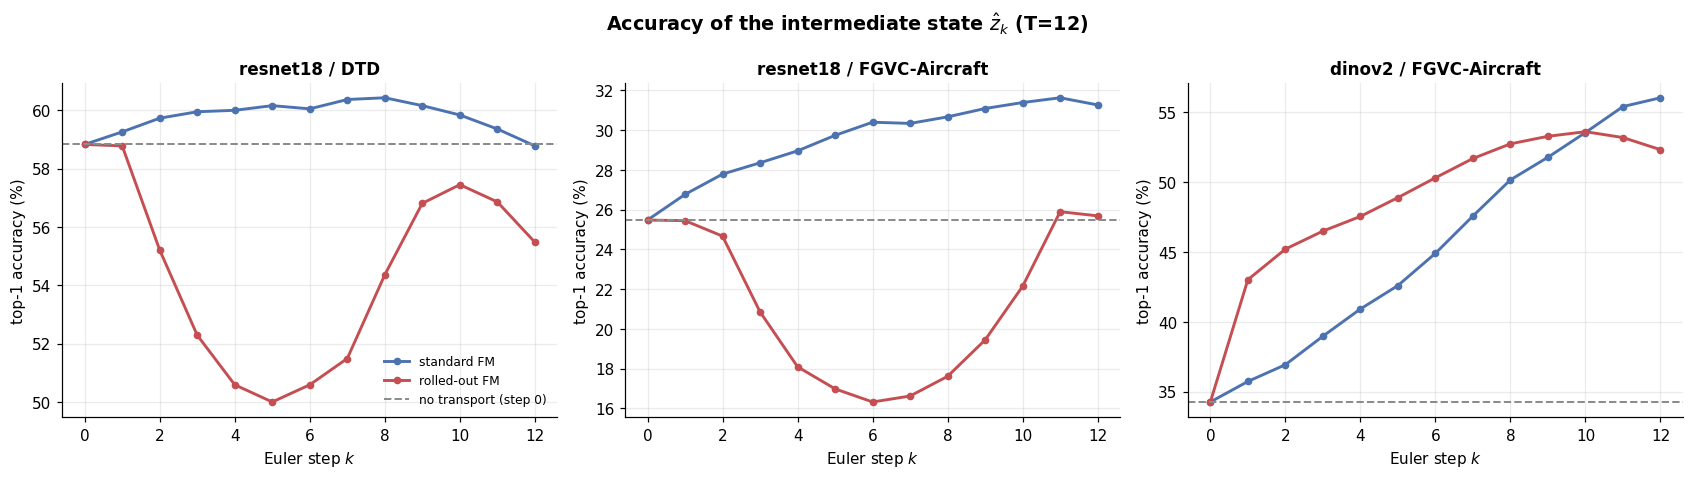

In [11]:
prog_rows = []
for enc, ds in COMBOS:
    te = load_features(enc, ds, "test")
    protos = prototypes[f"{enc}__{ds}__Kfull__seedNA"].to(DEVICE)
    z = l2_normalize(te.features).to(DEVICE)
    y = te.labels.to(DEVICE)

    for label, store in [("standard FM", std_models[f"{enc}__{ds}__Kfull__seed0"]),
                         ("rolled-out FM", roll_models[f"{enc}__{ds}__Kfull__seed0__T{T_TRAJECTORY}"])]:
        net = load_net(store, te.dim)
        with torch.no_grad():
            _, tr = euler_rollout(net, z, T_TRAJECTORY, return_trajectory=True)
            for k in range(T_TRAJECTORY + 1):
                preds = (l2_normalize(tr[:, k]) @ protos.T).argmax(1)
                prog_rows.append({
                    "encoder": enc, "dataset": ds, "method": label, "step": k,
                    "accuracy": round(100 * (preds == y).float().mean().item(), 2),
                })

progression = pd.DataFrame(prog_rows)
art.table(progression, "accuracy_by_step")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), sharex=True)
for ax, (enc, ds) in zip(axes, COMBOS):
    for label, c in [("standard FM", "#4C72B0"), ("rolled-out FM", "#C44E52")]:
        sel = progression[(progression.encoder == enc) & (progression.dataset == ds)
                          & (progression.method == label)]
        ax.plot(sel.step, sel.accuracy, marker="o", ms=4, lw=1.9, color=c, label=label)
    start = progression[(progression.encoder == enc) & (progression.dataset == ds)
                        & (progression.step == 0)].accuracy.iloc[0]
    ax.axhline(start, color="#8C8C8C", ls="--", lw=1.3, label="no transport (step 0)")
    ax.set_xlabel("Euler step $k$"); ax.set_ylabel("top-1 accuracy (%)")
    ax.set_title(f"{enc} / {ds}", fontsize=11)
    if ax is axes[0]:
        ax.legend(fontsize=8)

fig.suptitle(f"Accuracy of the intermediate state $\\hat z_k$ (T={T_TRAJECTORY})",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
art.figure(fig, "accuracy_by_step")
plt.show()

## 7 · Reverse flow

An exploration of the learned flow **backwards**, starting from the prototypes.
Integrating the same field in reverse,

$$\hat z_{k} = \hat z_{k+1} - \tfrac{1}{T}\,v_\theta\!\left(\hat z_{k+1}, \tfrac{k}{T}\right),$$

asks what a class prototype "unfolds" into.

**This is an extrapolation, and is labelled as such.** The network was only ever trained on
states produced by the *forward* pass; nothing constrains its behaviour on a reverse
trajectory, so the result is exploratory rather than evidence for any claim.

  saved plot  -> plots/reverse_flow.png


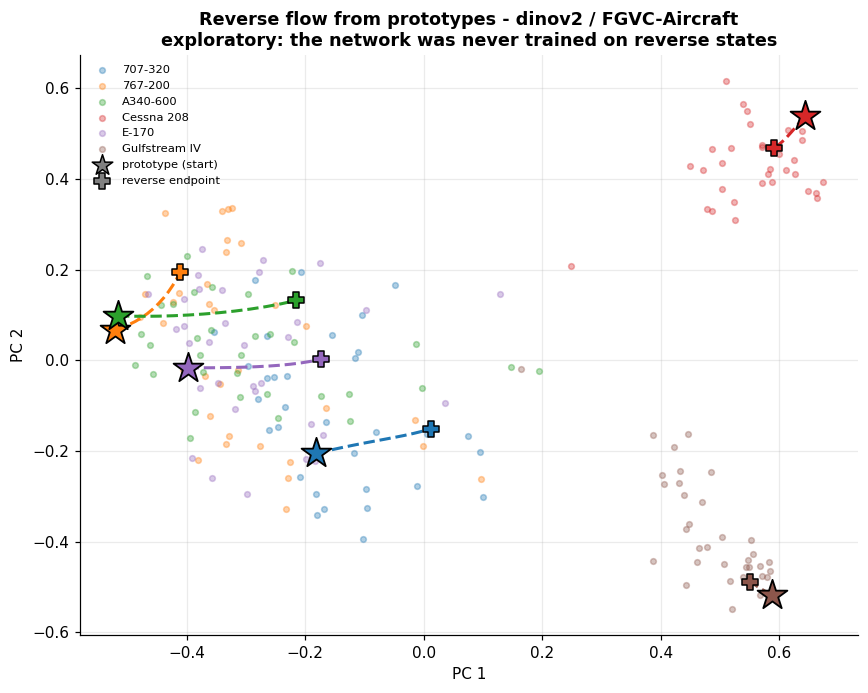

mean distance, features to their prototype : 0.7543
distance travelled by the reverse flow     : 0.4182


In [12]:
@torch.no_grad()
def reverse_rollout(net, z_end, T):
    z = z_end
    states = [z]
    for k in range(T - 1, -1, -1):
        t = torch.full((z.shape[0],), k / T, device=z.device, dtype=z.dtype)
        z = z - net(z, t) / T
        states.append(z)
    return torch.stack(states, dim=1)


enc, ds = "dinov2", "FGVC-Aircraft"
te = load_features(enc, ds, "test")
protos_all = prototypes[f"{enc}__{ds}__Kfull__seedNA"]
classes = np.arange(0, te.n_classes, max(1, te.n_classes // 6))[:6]

mask = np.isin(te.labels.numpy(), classes)
z0 = l2_normalize(te.features[mask])
y = te.labels[mask].numpy()

net = load_net(std_models[f"{enc}__{ds}__Kfull__seed0"], te.dim)
back = reverse_rollout(net, protos_all[classes].to(DEVICE), T_TRAJECTORY).cpu()

pca = PCA(n_components=2, random_state=0).fit(
    torch.cat([z0, back.reshape(-1, te.dim), protos_all[classes]]).numpy())

fig, ax = plt.subplots(figsize=(8, 6.4))
for j, c in enumerate(classes):
    sel = y == c
    pts = pca.transform(z0[sel].numpy())
    ax.scatter(pts[:, 0], pts[:, 1], s=14, alpha=0.35, color=PALETTE[j],
               label=te.classes[c][:16])
    path = pca.transform(back[j].numpy())
    ax.plot(path[:, 0], path[:, 1], color=PALETTE[j], lw=2.0, ls="--", zorder=4)
    ax.scatter(*path[0], marker="*", s=420, color=PALETTE[j],
               edgecolor="black", linewidth=1.2, zorder=6)
    ax.scatter(*path[-1], marker="P", s=110, color=PALETTE[j],
               edgecolor="black", linewidth=1.0, zorder=6)

ax.scatter([], [], marker="*", s=200, color="grey", edgecolor="black", label="prototype (start)")
ax.scatter([], [], marker="P", s=110, color="grey", edgecolor="black", label="reverse endpoint")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(fontsize=7.5, loc="best")
ax.set_title(f"Reverse flow from prototypes - {enc} / {ds}\n"
             "exploratory: the network was never trained on reverse states",
             fontsize=11.5, fontweight="bold")
fig.tight_layout()
art.figure(fig, "reverse_flow")
plt.show()

spread_fwd = (z0 - protos_all[torch.as_tensor(y)]).norm(dim=1).mean().item()
spread_back = (back[:, -1] - protos_all[classes]).norm(dim=1).mean().item()
print(f"mean distance, features to their prototype : {spread_fwd:.4f}")
print(f"distance travelled by the reverse flow     : {spread_back:.4f}")

## 8 · Save artefacts & manifest

In [13]:
methodology = pd.DataFrame([
    {"item": "scope", "value": "results 3 (feature-space) and 4 (flow trajectories)"},
    {"item": "models", "value": "representative runs only - full data, seed 0, from steps 2 and 3"},
    {"item": "training", "value": "none - forward rollouts on cached test features only"},
    {"item": "projection", "value": "PCA fitted JOINTLY over original + standard + rolled-out + prototypes"},
    {"item": "why joint", "value": "per-panel PCA would rescale each view independently and make panels incomparable"},
    {"item": "class subset", "value": f"{N_CLASSES_SHOWN} classes by even stride through the sorted list - not hand-picked"},
    {"item": "T (comparison)", "value": f"{T_COMPARE} - matches the headline results table"},
    {"item": "T (trajectories)", "value": f"{T_TRAJECTORY} - more intermediate states to visualise"},
    {"item": "quantitative backing", "value": "section 4 measures contraction in full dimensionality, not in 2D"},
    {"item": "reverse flow", "value": "exploratory only - the network was never trained on reverse states"},
])
art.table(methodology, "methodology")

art.manifest()

  saved table -> tables/methodology.csv  (10 rows)
13 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_2\Work\05_visualizations


,kind,file,size_KB
0,plot,plots/accuracy_by_step.png,126.0
1,plot,plots/contraction_measured.png,50.6
2,plot,plots/distance_by_step.png,174.5
3,plot,plots/feature_space_dinov2_aircraft.png,147.0
4,plot,plots/feature_space_resnet18_aircraft.png,160.8
5,plot,plots/feature_space_resnet18_dtd.png,160.8
6,plot,plots/flow_trajectories_dinov2.png,182.6
7,plot,plots/flow_trajectories_resnet18_dtd.png,181.7
8,plot,plots/reverse_flow.png,101.8
9,table,tables/accuracy_by_step.csv,3.2


---

## Stage 2 results — complete

| Result | Where |
| --- | --- |
| Classification results, $\Delta\mathrm{Acc}$, accuracy-vs-$K$ | step 4 |
| Training curves, both objectives | step 4 |
| Feature-space visualisations | **here** |
| Flow trajectories | **here** |
| Reverse flow | **here** |